In [79]:
# Step 1: Load and Preprocess the Breast Cancer Dataset
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [81]:
# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Normalize the dataset
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

# Split into training and validation sets
train_X, val_X, train_y, val_y = train_test_split(X, y, test_size=0.2, random_state=42)


In [83]:
# Step 2: Genetic Algorithm Setup
# Parameters
population_size = 20
num_generations = 50
mutation_rate = 0.01
k_range = (1, 10)  # Possible range of 'k' values for KNN

# Initialize population with random feature selection and k values
def initialize_population():
    population = []
    for _ in range(population_size):
        individual = {
            'features': np.random.randint(0, 2, size=X.shape[1]),  # Binary array for feature selection
            'k': np.random.randint(k_range[0], k_range[1]),        # Random k for KNN
            'fitness': 0                                           # Fitness score placeholder
        }
        population.append(individual)
    return population


In [85]:
# K-Nearest Neighbors (KNN) without inbuilt functions
def knn_predict(train_X, train_y, test_X, k):
    predictions = []
    for test_point in test_X:
        # Compute Euclidean distances
        distances = np.sqrt(np.sum((train_X - test_point) ** 2, axis=1))
        # Find the k nearest neighbors
        nearest_indices = np.argsort(distances)[:k]
        nearest_labels = train_y[nearest_indices]
        # Predict the most common label
        prediction = np.argmax(np.bincount(nearest_labels))
        predictions.append(prediction)
    return np.array(predictions)

In [87]:
# Evaluate fitness as classification accuracy
def evaluate_fitness(individual, train_X, train_y, val_X, val_y):
    # Select features based on individual's chromosome
    selected_features = np.where(individual['features'] == 1)[0]
    if len(selected_features) == 0:  # Avoid empty feature selection
        return 0
    # Train and validate KNN with selected features and given k
    pred_y = knn_predict(train_X[:, selected_features], train_y, val_X[:, selected_features], individual['k'])
    accuracy = np.mean(pred_y == val_y)
    return accuracy

In [89]:
# Selection: Roulette Wheel Selection
def selection(population):
    fitness_sum = sum(individual['fitness'] for individual in population)
    selection_probs = [individual['fitness'] / fitness_sum for individual in population]
    selected = np.random.choice(population, size=2, p=selection_probs)
    return selected

In [91]:

# Crossover: Single-point crossover
def crossover(parent1, parent2):
    child1, child2 = parent1.copy(), parent2.copy()
    crossover_point = np.random.randint(0, X.shape[1])
    child1['features'][:crossover_point], child2['features'][:crossover_point] = parent2['features'][:crossover_point], parent1['features'][:crossover_point]
    child1['k'], child2['k'] = parent2['k'], parent1['k']
    return child1, child2

In [93]:

# Mutation: Randomly toggle features and k values
def mutate(individual):
    for i in range(len(individual['features'])):
        if np.random.rand() < mutation_rate:
            individual['features'][i] = 1 - individual['features'][i]  # Toggle feature
    if np.random.rand() < mutation_rate:
        individual['k'] = np.random.randint(k_range[0], k_range[1])
    return individual

In [95]:
# Genetic Algorithm Main Loop
population = initialize_population()
best_accuracy = 0
accuracy_progression = []

for generation in range(num_generations):
    # Evaluate fitness for each individual
    for individual in population:
        individual['fitness'] = evaluate_fitness(individual, train_X, train_y, val_X, val_y)
    
    # Find the best individual in this generation
    population.sort(key=lambda x: x['fitness'], reverse=True)
    best_individual = population[0]
    
    # Track progress
    accuracy_progression.append(best_individual['fitness'])
    if best_individual['fitness'] > best_accuracy:
        best_accuracy = best_individual['fitness']
    
    # Selection and Generation of New Population
    new_population = []
    while len(new_population) < population_size:
        parent1, parent2 = selection(population)
        child1, child2 = crossover(parent1, parent2)
        new_population.extend([mutate(child1), mutate(child2)])
    
    # Replace old population with new one
    population = new_population[:population_size]

Best Features Selected: [ 1  2  6  7  8 11 12 13 19 20 23 24 25 27 28 29]
Best K: 7
Best Accuracy: 0.9912280701754386


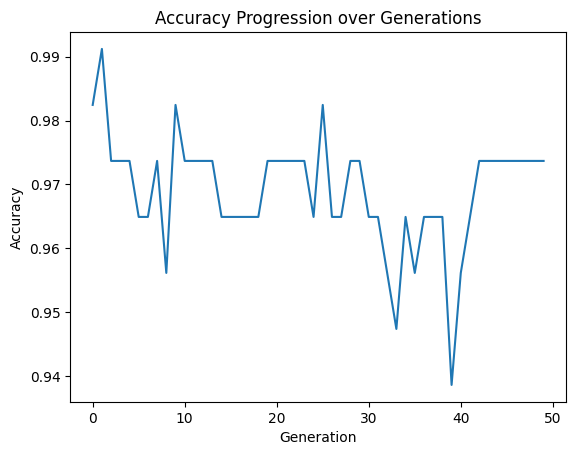

In [96]:
# Step 3: Display Best Result and Plot Accuracy Progression
print("Best Features Selected:", np.where(best_individual['features'] == 1)[0])
print("Best K:", best_individual['k'])
print("Best Accuracy:", best_accuracy)

# Plot Accuracy Progression
import matplotlib.pyplot as plt

plt.plot(range(num_generations), accuracy_progression)
plt.xlabel("Generation")
plt.ylabel("Accuracy")
plt.title("Accuracy Progression over Generations")
plt.show()